# 02 — Analyse Games

Load the simulated games from SQLite and extract:
- **Openings** (moves 1–6)
- **Mid-game tactics** (moves 7–16)
- **Late-game patterns** (move 17+)
- **Tactical move tags**

Produces visualisations and exports enriched data for the Strategy Book.

In [5]:
import os, sys, json
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter, defaultdict

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from engine.board import VERTICES, EDGES, ADJACENCY, HOME_BASES, apply_move_to_board
from engine.ai import get_all_possible_moves, apply_move_ai, is_game_over
from engine.positions import get_position

sns.set_theme(style='whitegrid')

DB_PATH = os.path.join('data', 'games.sqlite')
print(f"Loading from {DB_PATH}")

Loading from data/games.sqlite


## 1 — Load Data

In [6]:
conn = sqlite3.connect(DB_PATH)

games_df = pd.read_sql('SELECT * FROM games', conn)
moves_df = pd.read_sql('SELECT * FROM moves', conn)
conn.close()

print(f"Games: {len(games_df)}")
print(f"Moves: {len(moves_df)}")
print(f"\nWin distribution:")
print(games_df['winner'].value_counts())
print(f"\nTermination reasons:")
print(games_df['termination'].value_counts())

# Parse JSON columns
moves_df['strikes_list'] = moves_df['strikes'].apply(lambda s: json.loads(s) if s else [])
moves_df['upgrades_list'] = moves_df['upgrades'].apply(lambda s: json.loads(s) if s else [])
moves_df['num_strikes'] = moves_df['strikes_list'].apply(len)
moves_df['num_upgrades'] = moves_df['upgrades_list'].apply(len)

Games: 500
Moves: 10004

Win distribution:
winner
WHITE    250
BLACK    250
Name: count, dtype: int64

Termination reasons:
termination
no_legal_moves    500
Name: count, dtype: int64


## 2 — Phase Segmentation

| Phase | Move range | Rationale |
|---|---|---|
| **Opening** | 1–6 | First 3 moves per side |
| **Mid-game** | 7–16 | Core striking and upgrades |
| **Late-game** | 17+ | Endgame manoeuvring |

In [7]:
def assign_phase(move_number):
    if move_number <= 6:
        return 'opening'
    elif move_number <= 16:
        return 'midgame'
    else:
        return 'lategame'

moves_df['phase'] = moves_df['move_number'].apply(assign_phase)

# Dynamic phase boundaries: first strike and last upgrade per game
strike_moves = moves_df[moves_df['num_strikes'] > 0].groupby('game_id')['move_number']
first_strike = strike_moves.min().rename('first_strike_move')
last_strike = strike_moves.max().rename('last_strike_move')

upgrade_moves = moves_df[moves_df['num_upgrades'] > 0].groupby('game_id')['move_number']
first_upgrade = upgrade_moves.min().rename('first_upgrade_move')
last_upgrade = upgrade_moves.max().rename('last_upgrade_move')

phase_stats = pd.concat([first_strike, last_strike, first_upgrade, last_upgrade], axis=1)
phase_stats = games_df[['game_id', 'winner', 'total_moves']].merge(phase_stats, left_on='game_id', right_index=True, how='left')

print("Phase boundary stats (across all games):")
print(phase_stats[['first_strike_move', 'first_upgrade_move', 'last_upgrade_move']].describe().round(1))

Phase boundary stats (across all games):
       first_strike_move  first_upgrade_move  last_upgrade_move
count              500.0               127.0              127.0
mean                10.0                19.0               19.0
std                  0.0                 0.0                0.0
min                 10.0                19.0               19.0
25%                 10.0                19.0               19.0
50%                 10.0                19.0               19.0
75%                 10.0                19.0               19.0
max                 10.0                19.0               19.0


## 3 — Opening Analysis

In [8]:
# Extract the first 6 moves (3 per side) as an opening signature
opening_moves = moves_df[moves_df['move_number'] <= 6].sort_values(['game_id', 'move_number'])

def build_opening_signature(group):
    """Create a tuple of (from, to) for the first 6 moves."""
    moves = list(zip(group['from_vertex'], group['to_vertex']))
    return tuple(moves)

opening_sigs = opening_moves.groupby('game_id').apply(build_opening_signature).reset_index()
opening_sigs.columns = ['game_id', 'opening']
opening_sigs = opening_sigs.merge(games_df[['game_id', 'winner', 'total_moves']], on='game_id')

# Count frequency of each unique opening
opening_counts = Counter(opening_sigs['opening'])
top_openings = opening_counts.most_common(20)

print(f"Unique openings: {len(opening_counts)}")
print(f"\nTop 10 openings:")
for i, (opening, count) in enumerate(top_openings[:10], 1):
    pct = count / len(opening_sigs) * 100
    # Win rate for this opening
    mask = opening_sigs['opening'] == opening
    subset = opening_sigs[mask]
    white_wr = (subset['winner'] == 'WHITE').mean() * 100
    black_wr = (subset['winner'] == 'BLACK').mean() * 100
    moves_str = ' → '.join(f"{f}-{t}" for f, t in opening[:3])
    print(f"  {i:2d}. ({pct:5.1f}%) W:{white_wr:.0f}% B:{black_wr:.0f}% | {moves_str} ...")

Unique openings: 1

Top 10 openings:
   1. (100.0%) W:50% B:50% | C1-C12 → C7-C6 → C2-C3 ...


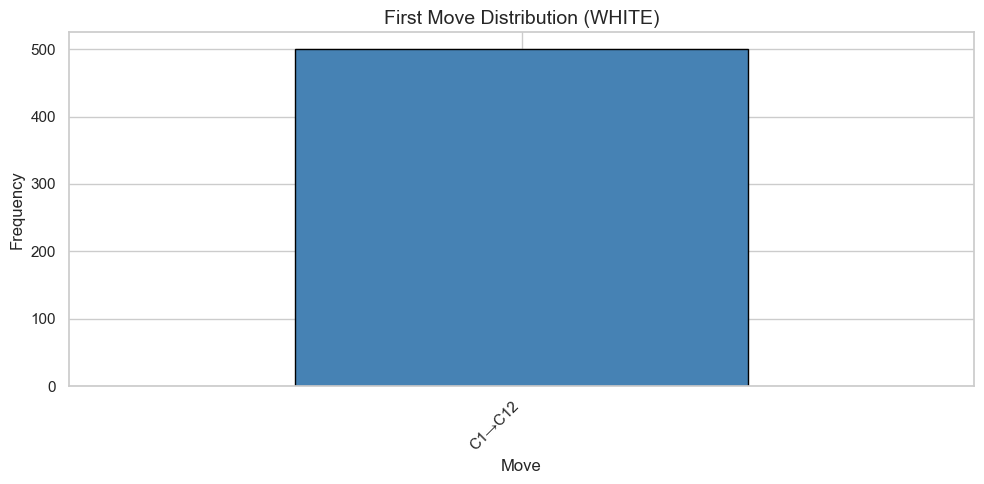

In [9]:
# Opening tree: build a trie of first moves
# Visualise as a bar chart of first WHITE move choices
first_white_moves = moves_df[(moves_df['move_number'] == 1) & (moves_df['color'] == 'WHITE')]
move_labels = first_white_moves['from_vertex'] + '→' + first_white_moves['to_vertex']

fig, ax = plt.subplots(figsize=(10, 5))
move_labels.value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('First Move Distribution (WHITE)', fontsize=14)
ax.set_xlabel('Move')
ax.set_ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4 — Mid-Game Strategy Analysis

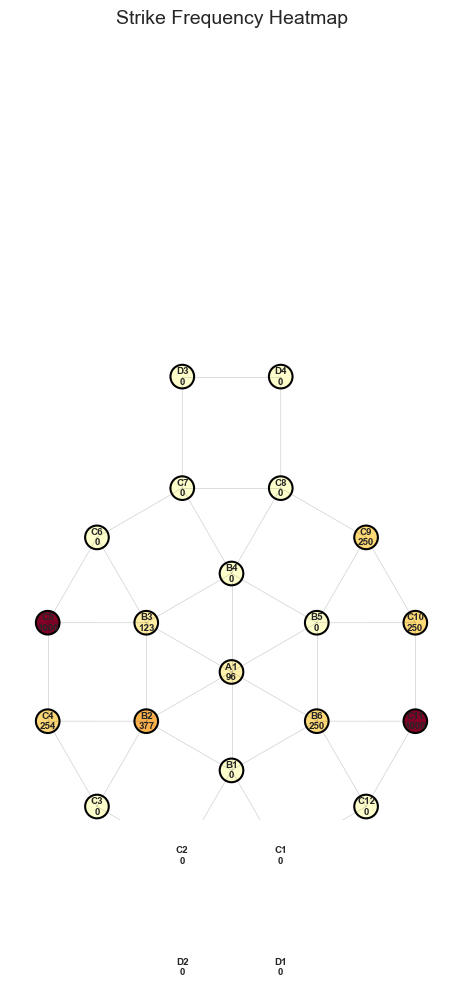

In [10]:
# 4.1 Strike frequency heatmap — which vertices are struck most often?
all_strikes = []
for strikes_json in moves_df['strikes']:
    if strikes_json:
        all_strikes.extend(json.loads(strikes_json))

strike_counter = Counter(all_strikes)

# Build a position-based heatmap
fig, ax = plt.subplots(figsize=(8, 10))
ax.set_aspect('equal')
ax.set_title('Strike Frequency Heatmap', fontsize=14)

# Get positions for plotting
max_strikes = max(strike_counter.values()) if strike_counter else 1

for v in VERTICES:
    x, y = get_position(v, width=250, height=500, v_width=100)
    count = strike_counter.get(v, 0)
    intensity = count / max_strikes if max_strikes > 0 else 0
    color = plt.cm.YlOrRd(intensity)
    circle = plt.Circle((x, -y), 12, color=color, ec='black', linewidth=1.5)
    ax.add_patch(circle)
    ax.text(x, -y, f"{v}\n{count}", ha='center', va='center', fontsize=7, fontweight='bold')

# Draw edges
for a, b in EDGES:
    xa, ya = get_position(a, width=250, height=500, v_width=100)
    xb, yb = get_position(b, width=250, height=500, v_width=100)
    ax.plot([xa, xb], [-ya, -yb], 'k-', alpha=0.2, linewidth=0.5)

ax.set_xlim(-100, 350)
ax.set_ylim(-400, 400)
ax.axis('off')
plt.tight_layout()
plt.show()

In [11]:
# 4.2 Strike chains — moves that flip 2+ pieces
multi_strikes = moves_df[moves_df['num_strikes'] >= 2].copy()

print(f"Moves with 2+ strikes: {len(multi_strikes)} ({len(multi_strikes)/len(moves_df)*100:.1f}% of all moves)")
print(f"\nStrike count distribution:")
print(moves_df['num_strikes'].value_counts().sort_index())

# Most common multi-strike landing positions
if len(multi_strikes) > 0:
    print(f"\nTop multi-strike landing vertices:")
    print(multi_strikes['to_vertex'].value_counts().head(10))

Moves with 2+ strikes: 425 (4.2% of all moves)

Strike count distribution:
num_strikes
0    6829
1    2750
2     425
Name: count, dtype: int64

Top multi-strike landing vertices:
to_vertex
B5    250
C3    127
B3     28
B1     20
Name: count, dtype: int64


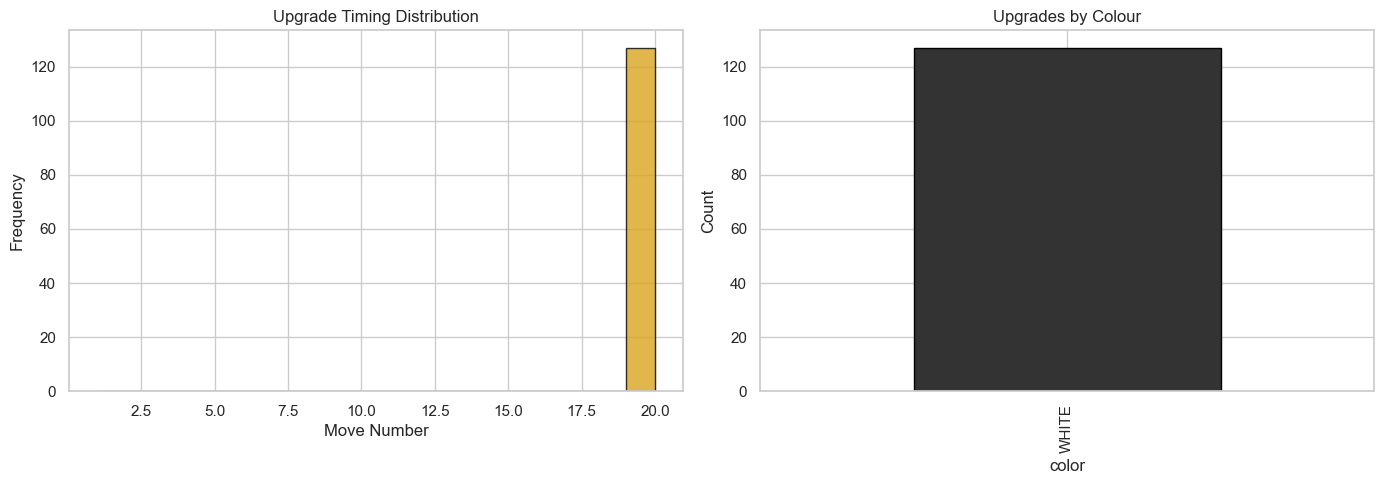


Upgrade → Win correlation: 100.0% of upgrades belong to the eventual winner


In [12]:
# 4.3 Upgrade timing — when do upgrades happen?
upgrade_df = moves_df[moves_df['num_upgrades'] > 0].copy()

if len(upgrade_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution of upgrade move numbers
    axes[0].hist(upgrade_df['move_number'], bins=range(1, upgrade_df['move_number'].max() + 2),
                 color='goldenrod', edgecolor='black', alpha=0.8)
    axes[0].set_title('Upgrade Timing Distribution', fontsize=12)
    axes[0].set_xlabel('Move Number')
    axes[0].set_ylabel('Frequency')
    
    # Upgrades by colour
    upgrade_df['color'].value_counts().plot(kind='bar', ax=axes[1],
                                            color=['#333', '#eee'], edgecolor='black')
    axes[1].set_title('Upgrades by Colour', fontsize=12)
    axes[1].set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    
    # Correlation with winning: do early upgraders win more?
    early_upgrades = upgrade_df.merge(games_df[['game_id', 'winner']], on='game_id')
    early_upgrades['upgraded_winner'] = early_upgrades['color'] == early_upgrades['winner']
    print(f"\nUpgrade → Win correlation: {early_upgrades['upgraded_winner'].mean()*100:.1f}% of upgrades belong to the eventual winner")
else:
    print("No upgrades found in the dataset.")

In [13]:
# 4.4 Positional control — most occupied vertices by winner at key moments
def get_board_at_move(game_id, move_number):
    """Get the board state after a specific move."""
    row = moves_df[(moves_df['game_id'] == game_id) & (moves_df['move_number'] == move_number)]
    if len(row) == 0:
        return None
    return json.loads(row.iloc[0]['board_after'])


def count_vertex_occupation(target_move, color_filter=None):
    """Count how often each vertex is occupied at a given move number."""
    occupation = Counter()
    relevant = moves_df[moves_df['move_number'] == target_move]
    
    for _, row in relevant.iterrows():
        board = json.loads(row['board_after'])
        winner = games_df[games_df['game_id'] == row['game_id']]['winner'].iloc[0]
        
        for vertex, checker in board.items():
            if color_filter is None or checker['color'] == winner:
                occupation[vertex] += 1
    
    return occupation


# Positional control at move 10 (mid-game) by the eventual winner
if len(moves_df[moves_df['move_number'] == 10]) > 0:
    winner_occupation_10 = count_vertex_occupation(10, color_filter='winner')
    print("Top vertices controlled by eventual winner at move 10:")
    for v, count in winner_occupation_10.most_common(10):
        print(f"  {v}: {count}")
else:
    print("Not enough games with 10+ moves for positional analysis.")

Top vertices controlled by eventual winner at move 10:
  C3: 250
  C1: 250
  C2: 250
  C6: 250
  C7: 250
  C8: 250
  C11: 250
  C10: 250


In [14]:
# 4.5 Tempo analysis — sequences of 3+ consecutive strikes by one player
def find_strike_sequences(min_length=3):
    """Find sequences of consecutive strikes by the same player."""
    sequences = []
    
    for game_id, group in moves_df.groupby('game_id'):
        group = group.sort_values('move_number')
        current_seq = []
        current_color = None
        
        for _, move in group.iterrows():
            if move['num_strikes'] > 0:
                if move['color'] == current_color:
                    current_seq.append(move)
                else:
                    if len(current_seq) >= min_length:
                        sequences.append({
                            'game_id': game_id,
                            'color': current_color,
                            'length': len(current_seq),
                            'start_move': current_seq[0]['move_number'],
                        })
                    current_seq = [move]
                    current_color = move['color']
            else:
                if move['color'] == current_color:
                    # Non-strike by same player breaks the sequence
                    if len(current_seq) >= min_length:
                        sequences.append({
                            'game_id': game_id,
                            'color': current_color,
                            'length': len(current_seq),
                            'start_move': current_seq[0]['move_number'],
                        })
                    current_seq = []
                    current_color = None
        
        # Check last sequence
        if len(current_seq) >= min_length:
            sequences.append({
                'game_id': game_id,
                'color': current_color,
                'length': len(current_seq),
                'start_move': current_seq[0]['move_number'],
            })
    
    return pd.DataFrame(sequences)


streak_df = find_strike_sequences(min_length=3)
if len(streak_df) > 0:
    print(f"Strike streaks (3+ consecutive): {len(streak_df)}")
    print(f"Average streak length: {streak_df['length'].mean():.1f}")
    print(f"Longest streak: {streak_df['length'].max()}")
else:
    print("No strike streaks of 3+ found.")

No strike streaks of 3+ found.


## 5 — Late-Game Analysis

In [15]:
# 5.1 Conversion patterns — how do the last 4-6 moves typically play out?
def get_last_n_moves(game_id, n=6):
    """Get the last n moves of a game."""
    game_moves = moves_df[moves_df['game_id'] == game_id].sort_values('move_number')
    return game_moves.tail(n)


# Cluster endings by termination type
conversion_games = games_df[games_df['termination'] == 'total_conversion']
stalemate_games = games_df[games_df['termination'] == 'no_legal_moves']

print(f"Games ending by total conversion: {len(conversion_games)}")
print(f"Games ending by no legal moves: {len(stalemate_games)}")
print(f"Games ending by move limit: {(games_df['termination'] == 'move_limit').sum()}")

# Last-move patterns for conversion games
if len(conversion_games) > 0:
    last_moves = []
    for gid in conversion_games['game_id'].head(100):  # Sample 100
        lm = get_last_n_moves(gid, 4)
        sig = tuple(zip(lm['from_vertex'], lm['to_vertex']))
        last_moves.append(sig)
    
    ending_counter = Counter(last_moves)
    print(f"\nUnique ending patterns (last 4 moves, sample of {min(100, len(conversion_games))} games): {len(ending_counter)}")
    print("Top 5 endings:")
    for pattern, count in ending_counter.most_common(5):
        moves_str = ' → '.join(f"{f}-{t}" for f, t in pattern)
        print(f"  ({count}x) {moves_str}")

Games ending by total conversion: 0
Games ending by no legal moves: 500
Games ending by move limit: 0


In [16]:
# 5.2 Upgraded piece dominance — win rate by upgrade count
def count_upgrades_at_end(game_id):
    """Count upgraded pieces for each colour at game end."""
    game_moves = moves_df[moves_df['game_id'] == game_id].sort_values('move_number')
    if len(game_moves) == 0:
        return {'white_upgrades': 0, 'black_upgrades': 0}
    
    last_board = json.loads(game_moves.iloc[-1]['board_after'])
    white_up = sum(1 for c in last_board.values() if c['color'] == 'WHITE' and c['isUpgraded'])
    black_up = sum(1 for c in last_board.values() if c['color'] == 'BLACK' and c['isUpgraded'])
    return {'white_upgrades': white_up, 'black_upgrades': black_up}


upgrade_counts = games_df['game_id'].apply(count_upgrades_at_end).apply(pd.Series)
upgrade_analysis = pd.concat([games_df[['game_id', 'winner']], upgrade_counts], axis=1)

# Win rate when having 2+ upgrades vs opponent with 0
dominant = upgrade_analysis[
    ((upgrade_analysis['white_upgrades'] >= 2) & (upgrade_analysis['black_upgrades'] == 0)) |
    ((upgrade_analysis['black_upgrades'] >= 2) & (upgrade_analysis['white_upgrades'] == 0))
]

if len(dominant) > 0:
    print(f"Games with upgrade dominance (2+ vs 0): {len(dominant)}")
    print(f"Dominant player win rate: ", end='')
    wins = 0
    for _, row in dominant.iterrows():
        if row['white_upgrades'] >= 2 and row['winner'] == 'WHITE':
            wins += 1
        elif row['black_upgrades'] >= 2 and row['winner'] == 'BLACK':
            wins += 1
    print(f"{wins/len(dominant)*100:.1f}%")
else:
    print("No games with clear upgrade dominance found.")

No games with clear upgrade dominance found.


In [17]:
# 5.3 Comeback frequency — games where a player was down to 1-2 pieces but won
def detect_comebacks():
    """Find games where the eventual winner was down to 1-2 pieces at some point."""
    comebacks = []
    
    for game_id in games_df['game_id']:
        winner = games_df[games_df['game_id'] == game_id]['winner'].iloc[0]
        if winner == 'DRAW':
            continue
        
        game_moves = moves_df[moves_df['game_id'] == game_id].sort_values('move_number')
        min_pieces = 4  # start with 4
        
        for _, move in game_moves.iterrows():
            board = json.loads(move['board_after'])
            winner_pieces = sum(1 for c in board.values() if c['color'] == winner)
            min_pieces = min(min_pieces, winner_pieces)
        
        if min_pieces <= 2:
            comebacks.append({
                'game_id': game_id,
                'winner': winner,
                'min_pieces': min_pieces,
                'total_moves': game_moves['move_number'].max(),
            })
    
    return pd.DataFrame(comebacks)


comeback_df = detect_comebacks()
if len(comeback_df) > 0:
    print(f"Comeback games (winner was down to ≤2 pieces): {len(comeback_df)}")
    print(f"  Down to 1 piece: {(comeback_df['min_pieces'] == 1).sum()}")
    print(f"  Down to 2 pieces: {(comeback_df['min_pieces'] == 2).sum()}")
    print(f"  Average game length: {comeback_df['total_moves'].mean():.1f}")
else:
    print("No comebacks detected.")

No comebacks detected.


## 6 — Tactical Move Tagging

Tag each move with tactical labels:
- `strike_single` / `strike_double` / `strike_triple`
- `upgrade_move` / `upgrade_strike`
- `centre_control` (move to A1 or B-ring)
- `home_invasion` (move into opponent's home-base zone)

In [18]:
B_RING = {'B1', 'B2', 'B3', 'B4', 'B5', 'B6'}
CENTRE_VERTICES = {'A1'} | B_RING


def tag_move(row):
    """Return a list of tactical tags for a single move."""
    tags = []
    n_strikes = row['num_strikes']
    n_upgrades = row['num_upgrades']
    to_v = row['to_vertex']
    color = row['color']
    
    # Strike tags
    if n_strikes == 1:
        tags.append('strike_single')
    elif n_strikes == 2:
        tags.append('strike_double')
    elif n_strikes >= 3:
        tags.append('strike_triple')
    
    # Upgrade tags
    upgrades = row['upgrades_list']
    if to_v in upgrades:
        tags.append('upgrade_move')  # mover upgraded
    struck_upgrades = [u for u in upgrades if u != to_v]
    if struck_upgrades:
        tags.append('upgrade_strike')  # struck piece upgraded
    
    # Positional tags
    if to_v in CENTRE_VERTICES:
        tags.append('centre_control')
    
    # Home invasion: moving into opponent's home-base zone
    opp_color = 'BLACK' if color == 'WHITE' else 'WHITE'
    if to_v in HOME_BASES[opp_color]:
        tags.append('home_invasion')
    
    return tags


moves_df['tags'] = moves_df.apply(tag_move, axis=1)
moves_df['tags_str'] = moves_df['tags'].apply(lambda t: ','.join(t) if t else '')

# Summary of tactical tags
all_tags = []
for tag_list in moves_df['tags']:
    all_tags.extend(tag_list)

tag_counter = Counter(all_tags)
print("Tactical tag frequency:")
for tag, count in tag_counter.most_common():
    pct = count / len(moves_df) * 100
    print(f"  {tag:20s}: {count:6d} ({pct:.1f}%)")

Tactical tag frequency:
  strike_single       :   2750 (27.5%)
  centre_control      :   2109 (21.1%)
  strike_double       :    425 (4.2%)
  upgrade_move        :    127 (1.3%)
  home_invasion       :    127 (1.3%)


## 7 — Export Enriched Data

In [19]:
# Write tagged moves and phase stats back to an analysis database
ANALYSIS_DB = os.path.join('data', 'analysis.sqlite')

conn = sqlite3.connect(ANALYSIS_DB)

# Export enriched moves
export_cols = ['move_id', 'game_id', 'move_number', 'color', 'from_vertex', 'to_vertex',
               'num_strikes', 'num_upgrades', 'phase', 'tags_str']
moves_df[export_cols].to_sql('tagged_moves', conn, if_exists='replace', index=False)

# Export opening signatures
opening_export = opening_sigs.copy()
opening_export['opening_str'] = opening_export['opening'].apply(
    lambda o: '|'.join(f"{f}-{t}" for f, t in o)
)
opening_export[['game_id', 'opening_str', 'winner', 'total_moves']].to_sql(
    'openings', conn, if_exists='replace', index=False
)

# Export phase boundary stats
phase_stats.to_sql('phase_stats', conn, if_exists='replace', index=False)

conn.close()
print(f"Enriched data exported to {ANALYSIS_DB}")

Enriched data exported to data/analysis.sqlite


## 8 — Visualisations

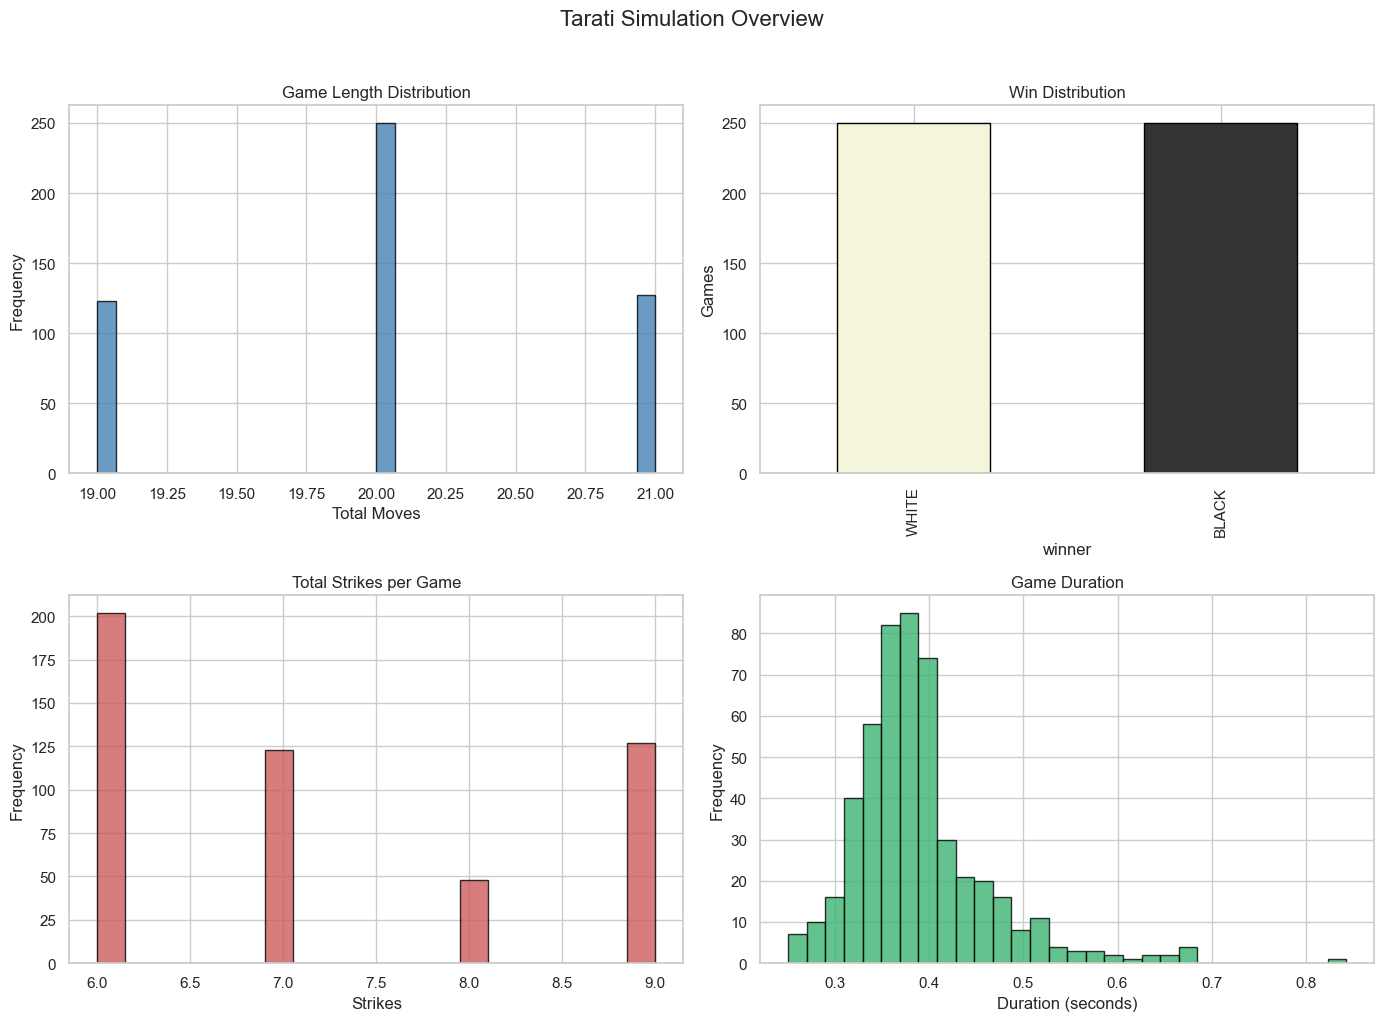

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 8.1 Game length distribution
axes[0, 0].hist(games_df['total_moves'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 0].set_title('Game Length Distribution')
axes[0, 0].set_xlabel('Total Moves')
axes[0, 0].set_ylabel('Frequency')

# 8.2 Win rate by colour
win_counts = games_df['winner'].value_counts()
colors_map = {'WHITE': '#f5f5dc', 'BLACK': '#333333', 'DRAW': '#888888'}
bar_colors = [colors_map.get(w, '#888') for w in win_counts.index]
win_counts.plot(kind='bar', ax=axes[0, 1], color=bar_colors, edgecolor='black')
axes[0, 1].set_title('Win Distribution')
axes[0, 1].set_ylabel('Games')

# 8.3 Strikes per game
strikes_per_game = moves_df.groupby('game_id')['num_strikes'].sum()
axes[1, 0].hist(strikes_per_game, bins=20, color='indianred', edgecolor='black', alpha=0.8)
axes[1, 0].set_title('Total Strikes per Game')
axes[1, 0].set_xlabel('Strikes')
axes[1, 0].set_ylabel('Frequency')

# 8.4 Game duration
axes[1, 1].hist(games_df['duration_ms'] / 1000, bins=30, color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[1, 1].set_title('Game Duration')
axes[1, 1].set_xlabel('Duration (seconds)')
axes[1, 1].set_ylabel('Frequency')

plt.suptitle('Tarati Simulation Overview', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

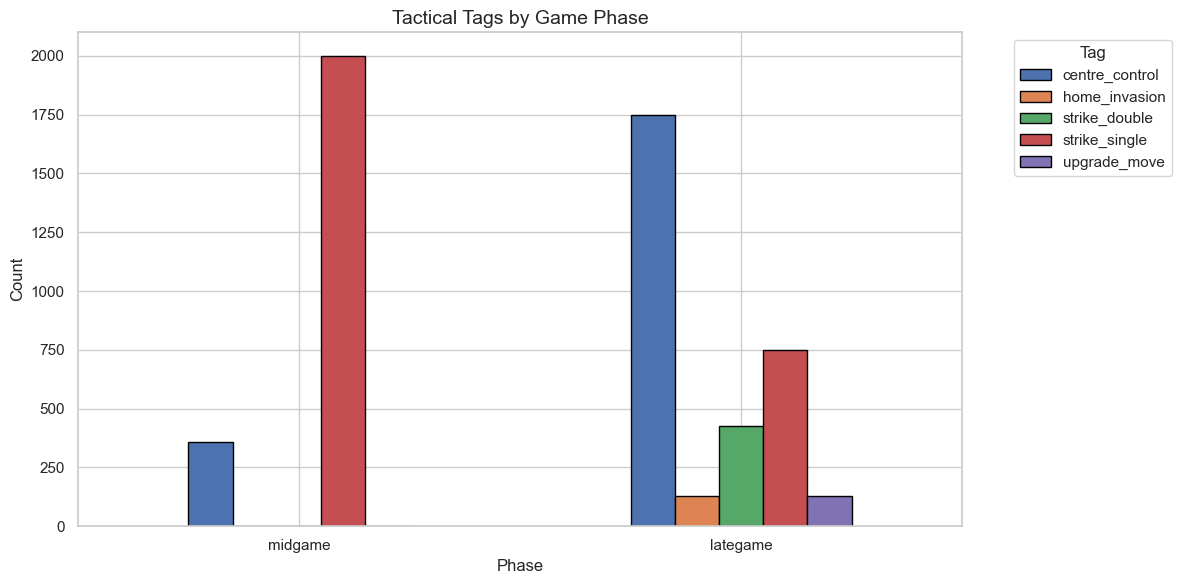

In [21]:
# 8.5 Tactical tag distribution by phase
phase_tag_data = []
for _, row in moves_df.iterrows():
    for tag in row['tags']:
        phase_tag_data.append({'phase': row['phase'], 'tag': tag})

if phase_tag_data:
    phase_tag_df = pd.DataFrame(phase_tag_data)
    pivot = phase_tag_df.groupby(['phase', 'tag']).size().unstack(fill_value=0)
    
    # Reorder phases
    phase_order = ['opening', 'midgame', 'lategame']
    pivot = pivot.reindex([p for p in phase_order if p in pivot.index])
    
    fig, ax = plt.subplots(figsize=(12, 6))
    pivot.plot(kind='bar', ax=ax, edgecolor='black')
    ax.set_title('Tactical Tags by Game Phase', fontsize=14)
    ax.set_xlabel('Phase')
    ax.set_ylabel('Count')
    ax.legend(title='Tag', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No tagged moves to visualise.")

In [22]:
# Final summary for the Strategy Book
print("=" * 60)
print("ANALYSIS COMPLETE — Ready for Strategy Book compilation")
print("=" * 60)
print(f"\nGames analysed: {len(games_df)}")
print(f"Total moves: {len(moves_df)}")
print(f"Unique openings: {len(opening_counts)}")
print(f"Tagged moves: {moves_df['tags_str'].astype(bool).sum()}")
print(f"\nData exported to: {ANALYSIS_DB}")
print(f"\nNext step: Run 03_strategy_book generation.")

ANALYSIS COMPLETE — Ready for Strategy Book compilation

Games analysed: 500
Total moves: 10004
Unique openings: 1
Tagged moves: 4363

Data exported to: data/analysis.sqlite

Next step: Run 03_strategy_book generation.
